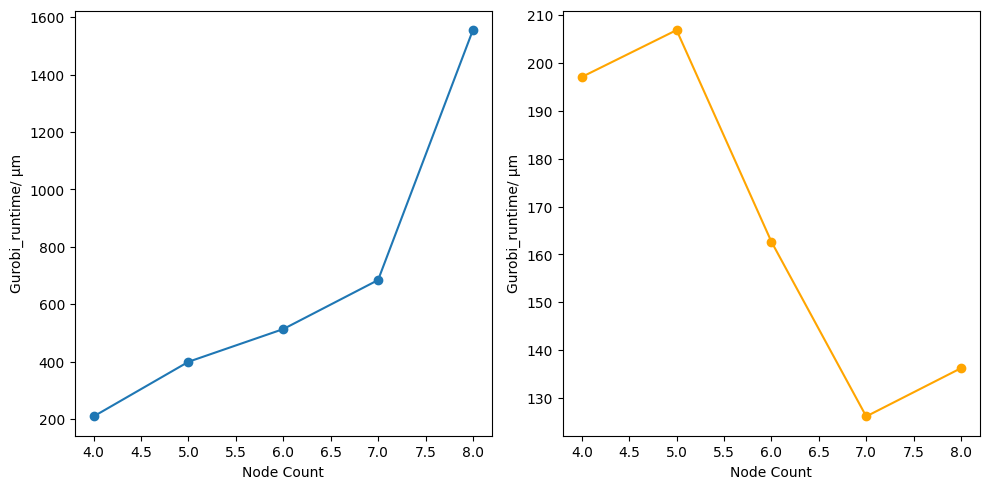

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import re

base_data = []
base_f_data = []

for file in os.listdir():
    if file.endswith('.csv'):
        #get average runtime
        node_num = int(file[3])
        df = pd.read_csv(file)
        avg_runtime = df['Gurobi_runtime/microseconds'].mean()

        #store data separately
        if 'f' in file:
            base_f_data.append((node_num, avg_runtime))
        else:
            base_data.append((node_num, avg_runtime))

#sort by node number
base_data.sort()
base_f_data.sort()

df_base = pd.DataFrame(base_data, columns=['nodes', 'Gurobi_runtime/microseconds'])
df_base_f = pd.DataFrame(base_f_data, columns=['nodes', 'Gurobi_runtime/microseconds'])

plt.figure(figsize=(10, 5))

#base
plt.subplot(1, 2, 1)
plt.plot(df_base['nodes'], df_base['Gurobi_runtime/microseconds'], marker='o')
plt.xlabel('Node Count')
plt.ylabel('Gurobi_runtime/ µm')

#base_fixed
plt.subplot(1, 2, 2)
plt.plot(df_base_f['nodes'], df_base_f['Gurobi_runtime/microseconds'], marker='o', color='orange')
plt.xlabel('Node Count')
plt.ylabel('Gurobi_runtime/ µm')

plt.tight_layout()
plt.show()